<a href="https://colab.research.google.com/github/MBR4V0/Python/blob/main/Parametros_UnderOver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Correção de Parametros - Underfitting e Overfitting

In [ ]:
# Carregando os pacotes
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn import tree

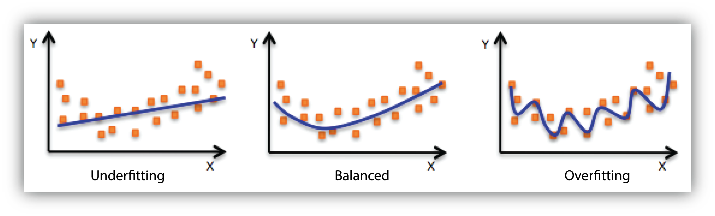

In [ ]:
# Vamos visualizar a imagem abaixo para começarmos entender melhor o Underfitting e Overfitting
img = Image.open('model.png')
img

## Vamos gerar um exemplo de Overfitting para analisarmos e entendermos claramente!

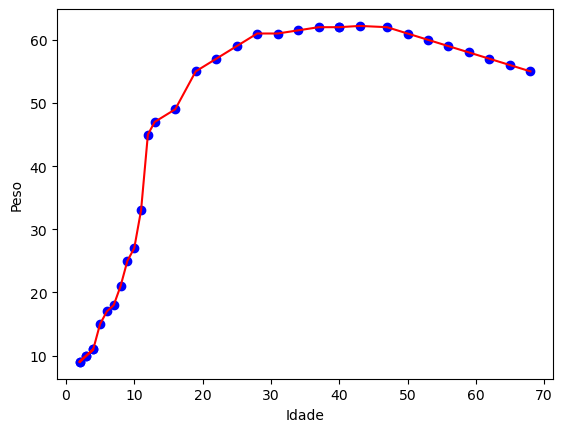

In [ ]:
# Criando um DataFrame com dados de exemplo

dados = [
        [2, 9],[3, 10],[4, 11],[2, 9],[3, 10],[4, 11],[5, 15],[6, 17],[7, 18],[8, 21],[9, 25],[10, 27],[11, 33],
        [12, 45],[13, 47],[16, 49],[19, 55],[22, 57],[25, 59],[28, 61],[31, 61],[34, 61.5],[37, 62],[40, 62],
        [40, 62],[43, 62.2],[47, 62],[50, 61],[53, 60],[56, 59],[59, 58],[62, 57],[65, 56],[68, 55],
        ]

df = pd.DataFrame(dados, columns=['Idade', 'Peso'])


# O X será nossa variável preditora
X = df['Idade'].values

# O Y será nossa variável target
Y = df['Peso'].values

# Fazendo o reshape para converter os dados de X em um Array
X = X.reshape(-1, 1)


# Criando nosso modelo de machine learning
modelo = tree.DecisionTreeRegressor()

# Treinando nosso modelo
modelo.fit(X, Y)

# Gerando as previsões
predicoes = modelo.predict(X)
predicoes

# Aqui claramente podemos avaliar uma situação de Overfitting
plt.scatter(X, Y, color = 'blue')
plt.plot(X, predicoes, color = 'red')
plt.xlabel("Idade")
plt.ylabel("Peso")
plt.show()



In [ ]:
# Outro dado de comprovar o Overfitting é avaliando o percentual de erro, como neste exemplo não houve nenhum erro.

Perc_Erro = mean_absolute_percentage_error(Y, predicoes) * 100
print('Percentual de Erro: ', round(Perc_Erro,2))

Percentual de Erro:  0.0


In [ ]:
# Avaliando e comparando os dados, podemos também comprovar que o modelo está acertando todos dados de treinamento

df['Peso_Previsao'] = predicoes
df.head(10)

,Idade,Peso,Peso_Previsao
0,2,9.0,9.0
1,3,10.0,10.0
2,4,11.0,11.0
3,2,9.0,9.0
4,3,10.0,10.0
5,4,11.0,11.0
6,5,15.0,15.0
7,6,17.0,17.0
8,7,18.0,18.0
9,8,21.0,21.0


## Vamos gerar um exemplo de Underfitting para analisarmos e entendermos claramente!

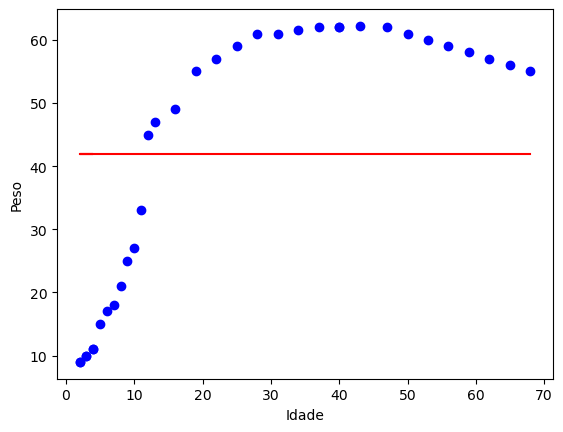

In [ ]:
# Criando um DataFrame com dados de exemplo
dados = [
        [2, 9],[3, 10],[4, 11],[2, 9],[3, 10],[4, 11],[5, 15],[6, 17],[7, 18],[8, 21],[9, 25],[10, 27],[11, 33],
        [12, 45],[13, 47],[16, 49],[19, 55],[22, 57],[25, 59],[28, 61],[31, 61],[34, 61.5],[37, 62],[40, 62],
        [40, 62],[43, 62.2],[47, 62],[50, 61],[53, 60],[56, 59],[59, 58],[62, 57],[65, 56],[68, 55]
        ]


df = pd.DataFrame(dados, columns=['Idade', 'Peso'])


# O X será nossa variável preditora
X = df['Idade'].values

# O Y será nossa variável target
Y = df['Peso'].values

# Fazendo o reshape para converter os dados de X em um Array
X = X.reshape(-1, 1)


# Criando nosso modelo de machine learning
modelo = tree.DecisionTreeRegressor(max_depth = 3, min_samples_leaf = 40)

# Treinando nosso modelo
modelo.fit(X, Y)

# Gerando as previsões
predicoes = modelo.predict(X)
predicoes

# Aqui claramente podemos avaliar uma situação de Underfitting
plt.scatter(X, Y, color = 'blue')
plt.plot(X, predicoes, color = 'red')
plt.xlabel("Idade")
plt.ylabel("Peso")
plt.show()

In [ ]:
# Outro dado de comprovar o Underfitting é avaliando o percentual de erro, como neste exemplo não houve nenhum erro.

erro = mean_absolute_percentage_error(Y, predicoes) * 100
print('Percentual de Erro: ', round(erro,2))

Percentual de Erro:  94.3


In [ ]:
# Avaliando e comparando os dados, podemos também comprovar que o modelo não aprendeu nada.
df['Peso_Previsao'] = predicoes
df.head(10)

,Idade,Peso,Peso_Previsao
0,2,9.0,41.991176
1,3,10.0,41.991176
2,4,11.0,41.991176
3,2,9.0,41.991176
4,3,10.0,41.991176
5,4,11.0,41.991176
6,5,15.0,41.991176
7,6,17.0,41.991176
8,7,18.0,41.991176
9,8,21.0,41.991176


In [ ]:
## Vamos gerar um exemplo de modelo com boa generalização dos dados, tal qual é a forma correta!

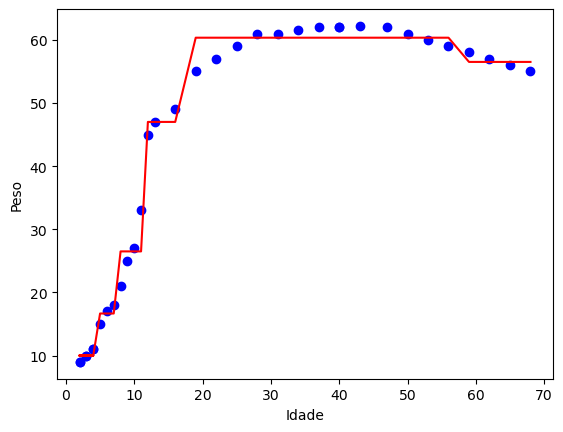

In [ ]:
# Criando um DataFrame com dados de exemplo
dados = [
        [2, 9],[3, 10],[4, 11],[2, 9],[3, 10],[4, 11],[5, 15],[6, 17],[7, 18],[8, 21],[9, 25],[10, 27],[11, 33],
        [12, 45],[13, 47],[16, 49],[19, 55],[22, 57],[25, 59],[28, 61],[31, 61],[34, 61.5],[37, 62],[40, 62],
        [40, 62],[43, 62.2],[47, 62],[50, 61],[53, 60],[56, 59],[59, 58],[62, 57],[65, 56],[68, 55],
        ]

df = pd.DataFrame(dados, columns=['Idade', 'Peso'])


# O X será nossa variável preditora
X = df['Idade'].values

# O Y será nossa variável target
Y = df['Peso'].values

# Fazendo o reshape para converter os dados de X em um Array
X = X.reshape(-1, 1)


# Criando nosso modelo de machine learning
modelo = tree.DecisionTreeRegressor(max_depth = 3, min_samples_split = 7)

# Treinando nosso modelo
modelo.fit(X, Y)

# Gerando as previsões
predicoes = modelo.predict(X)
predicoes

# Aqui claramente podemos avaliar que o modelo está tendo uma boa generalização
plt.scatter(X, Y, color = 'blue')
plt.plot(X, predicoes, color = 'red')
plt.xlabel("Idade")
plt.ylabel("Peso")
plt.show()

In [ ]:
# Outro dado de comprovar a boa generalização do modelo é através do percentual de erro
erro = mean_absolute_percentage_error(Y, predicoes) * 100
print('Percentual de Erro: ', round(erro,2))

Percentual de Erro:  4.99


In [ ]:
# Avaliando e comparando os dados, podemos também comprovar que o modelo está com uma taxa de erro boa.
df['Peso_Previsao'] = predicoes
df.head(10)

,Idade,Peso,Peso_Previsao
0,2,9.0,10.000000
1,3,10.0,10.000000
2,4,11.0,10.000000
3,2,9.0,10.000000
4,3,10.0,10.000000
5,4,11.0,10.000000
6,5,15.0,16.666667
7,6,17.0,16.666667
8,7,18.0,16.666667
9,8,21.0,26.500000


# Agora vamos ver com um conjunto de dados real como podemos avaliar o modelo e encontrar o melhor parametro!

In [ ]:
# Importando um conjunto de dados para demonstração
df = pd.read_csv('kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# Tamanho do conjunto de dados
df.shape

(21613, 21)

In [ ]:
# Variáveis Preditoras - Vamos considerar todas variáveis exceto as 3 variáveis abaixo que iremos excluir
X = df.drop(['price','date','id'], axis = 1)

# Variável Target/Alvo
Y = df['price'].copy()

In [ ]:
# Dividindo os dados em Dados de Treino e Dados de Teste
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = 0.3, random_state = 42)

In [ ]:
# Parametro com a quantidade de nós da arvore
max_depth = [1,2,3,4,5,6,7,8,9,10,12,13,14,15,16,17,18,19,20]

# Criando as listas vazias que irão receber o percentual de erro de cada treino e cada teste
lista_erro_treino = []
lista_erro_teste = []

# Loop For para fazermos a iteração do treinamento e validação do modelo
for i in max_depth:
    modelo = tree.DecisionTreeRegressor(max_depth = i)
    modelo.fit(X_treino, Y_treino)

    predicoes_treino = modelo.predict(X_treino)
    #mea_treino = mean_absolute_error(Y_treino, predicoes_treino)
    mape_treino = mean_absolute_percentage_error(Y_treino, predicoes_treino)
    lista_erro_treino.append(mape_treino)

    predicoes_teste = modelo.predict(X_teste)
    #mea_teste = mean_absolute_error(Y_teste, predicoes_teste)
    mape_teste = mean_absolute_percentage_error(Y_teste, predicoes_teste)
    lista_erro_teste.append(mape_teste)

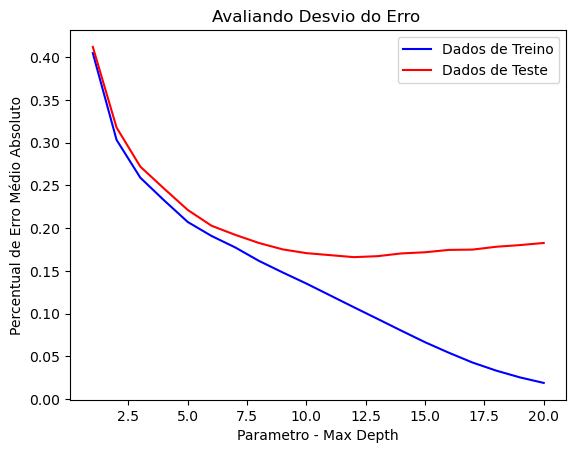

In [ ]:
# Gerando um gráfico para avaliarmos o melhor parametro para ajuste fino.
plt.plot(max_depth, lista_erro_treino, color = 'blue', label="Dados de Treino")
plt.plot(max_depth, lista_erro_teste, color = 'red', label="Dados de Teste")
plt.title("Avaliando Desvio do Erro ")
plt.legend(loc="upper right")
plt.xlabel("Parametro - Max Depth")
plt.ylabel("Percentual de Erro Médio Absoluto")
plt.show()

In [ ]:
# Criando o modelo após identificar o melhor parametro
modelo = tree.DecisionTreeRegressor(max_depth = 7)

# Treinando o modelo com o parametro adequado
modelo.fit(X_treino, Y_treino)

DecisionTreeRegressor(max_depth=7)

In [ ]:
# Gerando as predições de dados de teste
predicoes_teste = modelo.predict(X_teste)

# Verificando o percentual de erro do modelo
print("MAPE (Percentual Médio Erro Modelo): ", mean_absolute_percentage_error(Y_teste, predicoes_teste) * 100)


MAPE (Percentual Médio Erro Modelo):  19.157035701920226
